In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [2]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

# Load data

In [ ]:
data_uv = pd.read_excel('data/uv_spectra_synth.csv').dropna()

In [7]:
data_uv_np = data_uv.to_numpy()

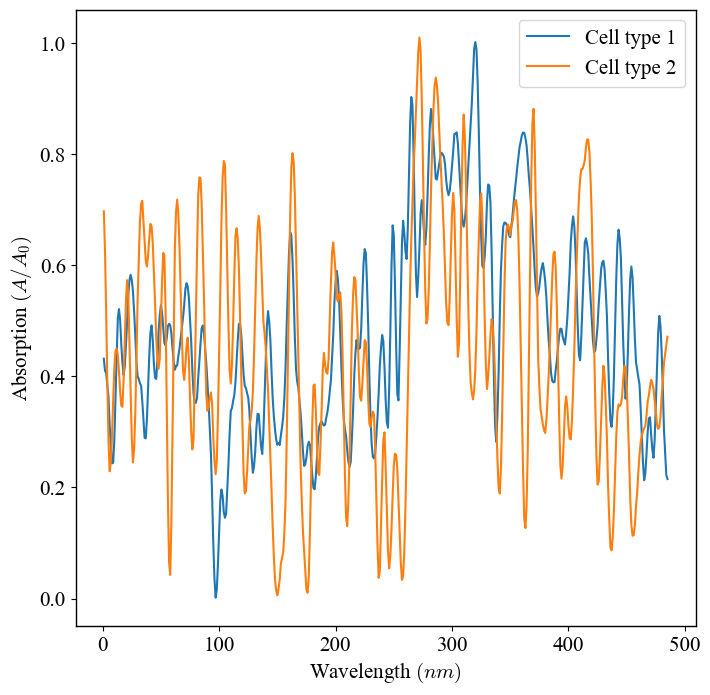

In [8]:
def plot_sample(data):
    '''
    Shows a visualization of the spectroscopic data

    Parameters
    ----------
    data : array
        dataset.

    Returns
    -------
    None.

    '''
    wl = np.linspace(1, 485, 485)
    sample1 = data[1, 2:]
    sample2 = data[623, 2:]
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(wl, sample1, label = 'Cell type 1')
    ax.plot(wl, sample2, label = 'Cell type 2')
    ax.set_xlabel('Wavelength $(nm)$')
    ax.set_ylabel('Absorption $(A/A_{0})$')
    plt.legend()
    plt.rcParams['mathtext.fontset'] = 'cm'
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman"
                                    ] + plt.rcParams["font.serif"]
    plt.rcParams['font.size']=15
    plt.rcParams['axes.linewidth'] = 1 

    plt.savefig(f'figures/example-9-1-convnet_data.png', dpi = 300)
    plt.show()

plot_sample(data_uv_np)

# Setup convolutional neural network

In [9]:
#Utility functions
def get_device():
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu'
    return device

In [10]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
    
        #Convolutional neural network
        self.conv1 = nn.Conv1d(in_channels = 1, out_channels = 3, kernel_size = 1)
        #self.pool = nn.MaxPool1d(3, stride = 1, padding = 1)
        #self.conv2 = nn.Conv1d(200, 100, 25)
        self.fc1 = nn.Linear(in_features = 3*485, out_features = 500)
        self.fc2 = nn.Linear(in_features = 500, out_features = 250)
        self.fc3 = nn.Linear(in_features = 250, out_features = 3)
    
    def forward(self, x):
        x = self.conv1(x)
        #x = self.pool(F.relu(self.conv1(x)))
        #x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 3*485)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        
        return x

class Model(Net):
    def __init__(self):
        super(Model, self).__init__()

    #Train 
    def train(self, X_train, y_train):
        self.net = Model()
        epochs = 50
        learning_rate = 0.001
        batch_size = 100
        
        #Define loss function and optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(self.net.parameters(), lr = learning_rate)
        
        device = get_device()
        
        trainset = []
        
        for i in range(len(X_train)):
           trainset.append([X_train[i], y_train[i]])
           
        trainloader = DataLoader(trainset, batch_size = batch_size, shuffle = True)
        
        train_loss = []
        for epoch in range(epochs):
            running_loss = 0.0
            
            for i, data in enumerate(trainloader, 0):
                # get the inputs; data is a list of [inputs, labels]
                x, labels = data
                
                optimizer.zero_grad()
                
                outputs = self.net(x.unsqueeze(1).float())
                
                loss = criterion(outputs, labels.long())
                loss.backward()
                
                optimizer.step()
               
                running_loss += loss.item()
            
            loss = running_loss/len(trainloader)
            train_loss.append(loss)
            print('Epoch {} of {}, Train Loss: {:.3f}'.format(epoch+1, epochs, loss))
        
               
        return train_loss
    
    def predict(self, inputs):
        
        inputs = torch.from_numpy(inputs)
        
        predicted = torch.max(self.net(inputs.unsqueeze(1).float()).data, 1)

        return predicted

# Use model
Predict type for group 3

Epoch 1 of 50, Train Loss: 1.122
Epoch 2 of 50, Train Loss: 1.053
Epoch 3 of 50, Train Loss: 0.917
Epoch 4 of 50, Train Loss: 0.692
Epoch 5 of 50, Train Loss: 0.496
Epoch 6 of 50, Train Loss: 0.358
Epoch 7 of 50, Train Loss: 0.363
Epoch 8 of 50, Train Loss: 0.316
Epoch 9 of 50, Train Loss: 0.321
Epoch 10 of 50, Train Loss: 0.298
Epoch 11 of 50, Train Loss: 0.271
Epoch 12 of 50, Train Loss: 0.263
Epoch 13 of 50, Train Loss: 0.232
Epoch 14 of 50, Train Loss: 0.220
Epoch 15 of 50, Train Loss: 0.220
Epoch 16 of 50, Train Loss: 0.230
Epoch 17 of 50, Train Loss: 0.253
Epoch 18 of 50, Train Loss: 0.229
Epoch 19 of 50, Train Loss: 0.200
Epoch 20 of 50, Train Loss: 0.214
Epoch 21 of 50, Train Loss: 0.190
Epoch 22 of 50, Train Loss: 0.192
Epoch 23 of 50, Train Loss: 0.203
Epoch 24 of 50, Train Loss: 0.225
Epoch 25 of 50, Train Loss: 0.214
Epoch 26 of 50, Train Loss: 0.194
Epoch 27 of 50, Train Loss: 0.185
Epoch 28 of 50, Train Loss: 0.188
Epoch 29 of 50, Train Loss: 0.172
Epoch 30 of 50, Train L

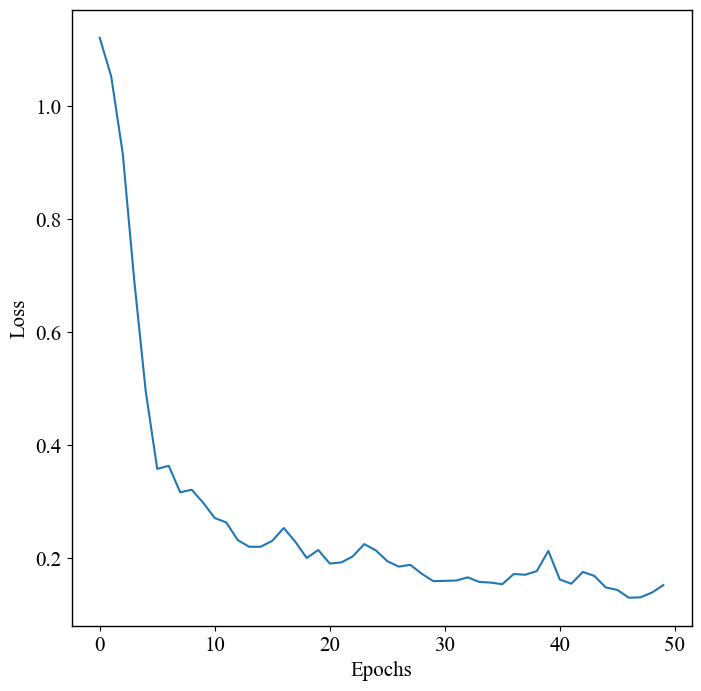

In [11]:
err = 0
i = 3

train = data_uv_np[data_uv_np[:, 0] != i]
test = data_uv_np[data_uv_np[:, 0] == i]
X_train, y_train = train[:, 2:], train[:, 1]
X_test, y_test = test[:, 2:], test[:, 1]

m = Model()
loss = m.train(X_train, y_train)

y_pred = m.predict(X_test)
err = np.sum(y_pred != y_test)

total_accuracy = 1 - err/len(data_uv_np)

print(f'Total_accuracy: {total_accuracy:.2f}')

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(loss)

ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 

plt.savefig(f'figures/example-9-1-convnet_loss.png', dpi = 300)
plt.show()
